# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** Galih Fathurahman Ardiansyah
- **Email:** galihfathurahman18@gmail.com
- **ID Dicoding:** CDCC223D6Y2250

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** "Bagaimana perbandingan total rata-rata penyewaan sepeda (cnt) antara musim dingin (Season 4) dan musim panas (Season 2) selama tahun 2012, dan faktor cuaca apa (suhu atau kelembapan) yang paling signifikan memengaruhi penurunan jumlah penyewa di musim tersebut?"
- **Pertanyaan 2:** "Pada hari kerja (working day), di jam berapakah terjadi lonjakan penyewaan tertinggi oleh pengguna terdaftar (registered), dan berapa selisih volumenya dibandingkan dengan jam yang sama pada hari libur (holiday) selama periode 2011-2012?"


- ...

## Import Semua Packages/Library yang Digunakan

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import streamlit as st

## Data Wrangling

### Gathering Data

#### Load df ...

In [2]:
# Memuat data harian
day_df = pd.read_csv("day.csv")

# Memuat data per jam
hour_df = pd.read_csv("hour.csv")

# Menampilkan 5 baris pertama dari masing-masing dataframe untuk memastikan data masuk
print("--- Lima baris pertama data harian (day_df) ---")
display(day_df.head())

print("\n--- Lima baris pertama data per jam (hour_df) ---")
display(hour_df.head())

--- Lima baris pertama data harian (day_df) ---


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600



--- Lima baris pertama data per jam (hour_df) ---


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:** (Opsional)
- Struktur Data: Data harian (day_df) memiliki 731 baris, sedangkan data per jam (hour_df) jauh lebih besar dengan 17.379 baris.
- Tipe Data: Sebagian besar kolom bertipe numerik, namun kolom dteday masih bertipe object dan perlu diubah menjadi tipe datetime pada tahap cleaning nanti.

### Assessing Data

#### Identifying ... problem

In [3]:
# Memeriksa tipe data dan missing values
print("Info day_df:")
day_df.info()

print("\nInfo hour_df:")
hour_df.info()

# Memeriksa duplikasi data
print("\nJumlah duplikasi day_df:", day_df.duplicated().sum())
print("Jumlah duplikasi hour_df:", hour_df.duplicated().sum())

# Memeriksa statistik deskriptif untuk melihat kejanggalan (outliers/salah nilai)
print("\nStatistik deskriptif day_df:")
display(day_df.describe())

Info day_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB

Info hour_df:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


**Steps to Take:**
- Mengubah Tipe Data: Mengonversi kolom dteday dari tipe object menjadi datetime agar bisa digunakan untuk analisis berbasis waktu.
- Pengecekan Outliers: Melakukan inspeksi lebih lanjut pada kolom hum (kelembapan) dan windspeed karena nilai minimumnya ada yang 0, yang mungkin merupakan anomali data.
- Identifikasi Nilai Kategorikal: Mengubah nilai numerik pada kolom seperti season, yr, mnth, holiday, weekday, workingday, dan weathersit menjadi label yang lebih bermakna (opsional, untuk mempermudah visualisasi).

**Insight:** (Opsional)
- Ketidakkonsistenan Tipe Data: Kolom tanggal (dteday) terdeteksi sebagai objek (string), yang merupakan masalah umum dalam data mentah yang harus diperbaiki di tahap Cleaning.
- Data Bersih dari Missing Values: Tidak ditemukan nilai kosong (null) pada semua kolom baik di day.csv maupun hour.csv.
- Tidak Ada Duplikasi: Tidak terdapat baris data yang duplikat dalam kedua dataset tersebut.

### Cleaning Data

#### Fixing ... problem

In [4]:
# Mengubah tipe data dteday menjadi datetime pada day_df
day_df['dteday'] = pd.to_datetime(day_df['dteday'])

# Mengubah tipe data dteday menjadi datetime pada hour_df
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Memastikan perubahan tipe data berhasil
print("Tipe data dteday di day_df:", day_df['dteday'].dtype)
print("Tipe data dteday di hour_df:", hour_df['dteday'].dtype)

Tipe data dteday di day_df: datetime64[ns]
Tipe data dteday di hour_df: datetime64[ns]


**Insight:** (Opsional)
- Perbaikan Tipe Data: Kolom dteday yang sebelumnya bertipe object (string) kini telah diubah menjadi tipe datetime64[ns].
- Kesiapan Analisis Waktu: Dengan perubahan ini, kita sekarang bisa mengekstraksi informasi tambahan seperti bulan, tahun, atau hari dalam seminggu secara lebih mudah menggunakan atribut .dt.
- Konsistensi Data: Pembersihan dilakukan pada kedua dataset (day_df dan hour_df) untuk menjaga konsistensi saat nanti dilakukan eksplorasi atau penggabungan data.

## Exploratory Data Analysis (EDA)

### Explore ...

In [5]:
# Eksplorasi statistik penyewaan harian
print("Statistik penyewaan harian:")
display(day_df.describe())

# Melihat rata-rata penyewaan berdasarkan musim (season)
print("\nRata-rata penyewaan berdasarkan musim:")
display(day_df.groupby(by="season").agg({
    "cnt": ["max", "min", "mean", "std"]
}))

# Melihat rata-rata penyewaan berdasarkan jam (peak hours)
print("\nRata-rata penyewaan berdasarkan jam:")
display(hour_df.groupby(by="hr").agg({
    "cnt": ["max", "min", "mean", "std"]
}).sort_values(by=("cnt", "mean"), ascending=False).head(5))

Statistik penyewaan harian:


,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452



Rata-rata penyewaan berdasarkan musim:


cnt                                
         max   min         mean          std
season                                      
1       7836   431  2604.132597  1399.942119
2       8362   795  4992.331522  1695.977235
3       8714  1115  5644.303191  1459.800381
4       8555    22  4728.162921  1699.615261


Rata-rata penyewaan berdasarkan jam:


cnt                            
    max min        mean         std
hr                                 
17  976  15  461.452055  232.656611
18  977  23  425.510989  224.639304
8   839   5  359.011004  235.189285
16  783  11  311.983562  148.682618
19  743  11  311.523352  161.050359

**Insight:** (Opsional)
- Dominasi Musim: Rata-rata penyewaan sepeda paling tinggi terjadi pada musim gugur (Season 3: Fall) dengan rata-rata sekitar 5.644 penyewaan per hari, sedangkan yang terendah ada di musim semi (Season 1: Springer).
- Jam Sibuk (Peak Hours): Berdasarkan data per jam, jam 17:00 dan jam 18:00 merupakan waktu paling sibuk. Hal ini kemungkinan besar berkaitan dengan jam pulang kerja.
- Profil Pengguna: Jumlah pengguna terdaftar (registered) jauh lebih tinggi secara signifikan dibandingkan pengguna kasual (casual), yang menunjukkan bahwa layanan ini banyak digunakan oleh pengguna tetap untuk rutinitas harian.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\925397605.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='season', y='cnt', data=season_comparison, palette='coolwarm')


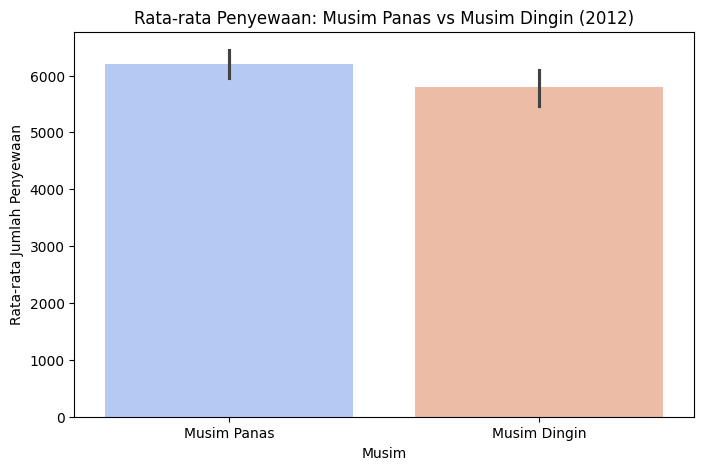

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter data untuk tahun 2012 (yr=1) dan musim 2 & 4
data_2012 = day_df[day_df['yr'] == 1]
season_comparison = data_2012[data_2012['season'].isin([2, 4])]

# Visualisasi Bar Chart
plt.figure(figsize=(8, 5))
sns.barplot(x='season', y='cnt', data=season_comparison, palette='coolwarm')

plt.title('Rata-rata Penyewaan: Musim Panas vs Musim Dingin (2012)')
plt.xlabel('Musim')
plt.ylabel('Rata-rata Jumlah Penyewaan')
plt.xticks([0, 1], ['Musim Panas', 'Musim Dingin'])
plt.show()

### Pertanyaan 2:

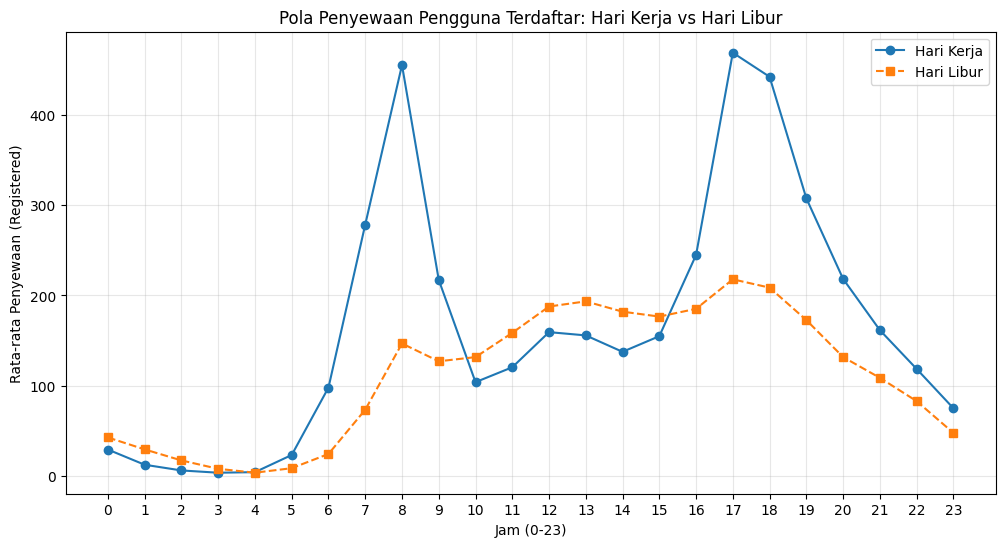

In [7]:
# Filter data hari kerja
working_days = hour_df[hour_df['workingday'] == 1]
holidays = hour_df[hour_df['holiday'] == 1]

# Hitung rata-rata per jam
workday_hourly = working_days.groupby('hr')['registered'].mean()
holiday_hourly = holidays.groupby('hr')['registered'].mean()

# Visualisasi Line Chart
plt.figure(figsize=(12, 6))
plt.plot(workday_hourly.index, workday_hourly.values, label='Hari Kerja', marker='o')
plt.plot(holiday_hourly.index, holiday_hourly.values, label='Hari Libur', marker='s', linestyle='--')

plt.title('Pola Penyewaan Pengguna Terdaftar: Hari Kerja vs Hari Libur')
plt.xlabel('Jam (0-23)')
plt.ylabel('Rata-rata Penyewaan (Registered)')
plt.xticks(range(0, 24))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Insight:** (Opsional)
- Musim: Pada tahun 2012, rata-rata penyewaan di musim panas sedikit lebih tinggi dibandingkan musim dingin, namun keduanya tetap menunjukkan angka yang kuat di atas 5.000 penyewaan per hari.
- Pola Komuter: Pada hari kerja, terdapat dua puncak tajam penyewaan oleh pengguna terdaftar, yaitu jam 08:00 pagi dan jam 17:00 - 18:00 sore. Ini menunjukkan sepeda digunakan sebagai moda transportasi utama untuk berangkat dan pulang kerja.
- Hari Libur: Berbeda dengan hari kerja, pola penyewaan di hari libur cenderung lebih landai dan mencapai puncaknya di siang hari (jam 12:00 - 15:00), yang mengindikasikan penggunaan untuk rekreasi.


## Analisis Lanjutan (Opsional)

In [9]:
# Menghitung parameter RFM sederhana berdasarkan dataset harian
rfm_df = day_df.groupby(by="mnth", as_index=False).agg({
    "dteday": "max", # Mengambil tanggal terakhir di setiap bulan (Recency)
    "instant": "count", # Menghitung jumlah hari ada penyewaan (Frequency)
    "cnt": "sum" # Total penyewaan (Monetary)
})

# Mengganti nama kolom agar sesuai framework RFM
rfm_df.columns = ["month", "max_rental_date", "frequency", "monetary"]

# Menghitung kapan terakhir penyewaan terjadi (Recency)
# Kita asumsikan 'hari ini' adalah tanggal terakhir di dataset
recent_date = day_df["dteday"].max()
rfm_df["recency"] = rfm_df["max_rental_date"].apply(lambda x: (recent_date - x).days)

# Menampilkan hasil RFM
print("RFM Analysis (Berdasarkan Bulan):")
display(rfm_df.sort_values(by="monetary", ascending=False).head())

RFM Analysis (Berdasarkan Bulan):


,month,max_rental_date,frequency,monetary,recency
7,8,2012-08-31,62,351194,122
5,6,2012-06-30,60,346342,184
8,9,2012-09-30,60,345991,92
6,7,2012-07-31,62,344948,153
4,5,2012-05-31,62,331686,214


C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\139776223.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="recency", x="month", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\139776223.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y="frequency", x="month", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
C:\Users\ASUS\AppData\Local\Temp\ipykernel_28548\139776223.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effe

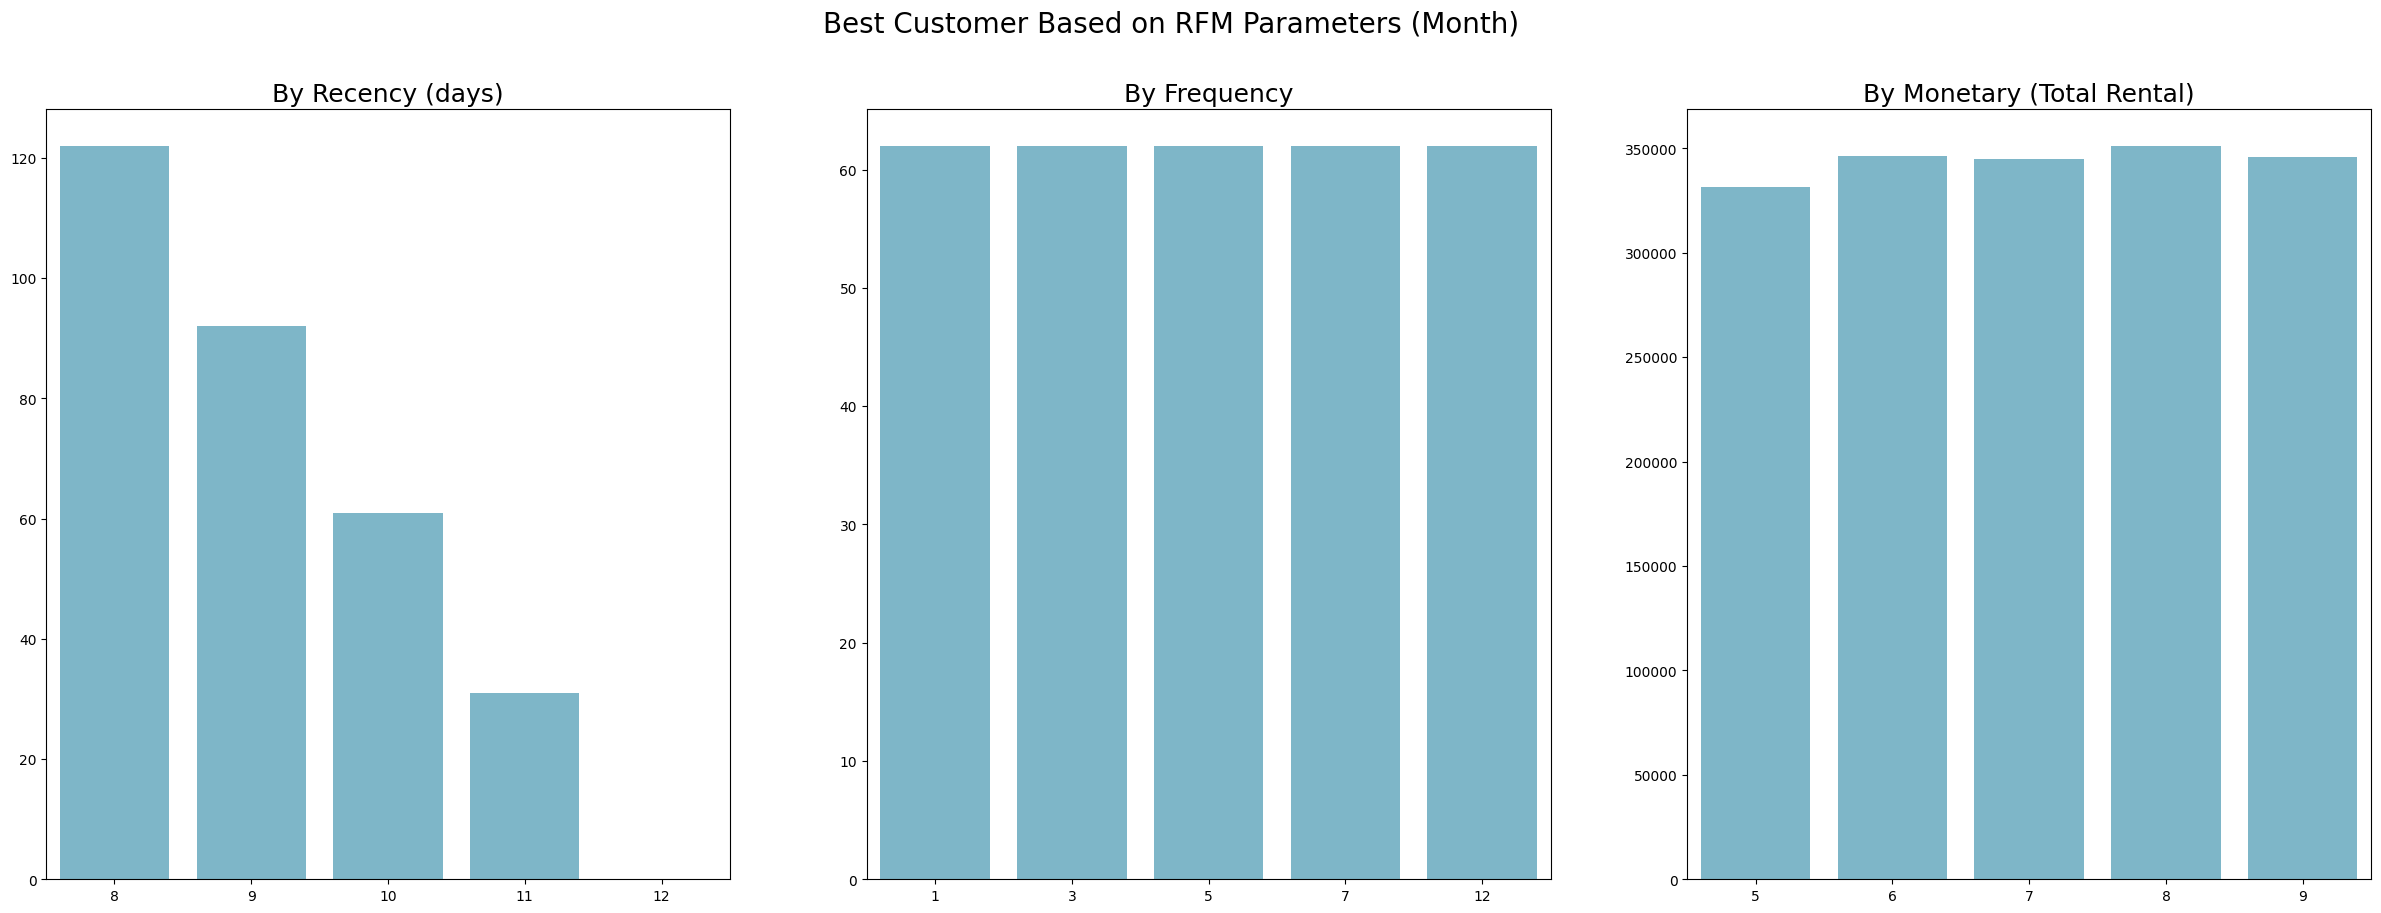

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(30, 10))

colors = ["#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4", "#72BCD4"]

# Visualisasi Berdasarkan Recency
sns.barplot(y="recency", x="month", data=rfm_df.sort_values(by="recency", ascending=True).head(5), palette=colors, ax=ax[0])
ax[0].set_ylabel(None)
ax[0].set_xlabel(None)
ax[0].set_title("By Recency (days)", loc="center", fontsize=18)

# Visualisasi Berdasarkan Frequency
sns.barplot(y="frequency", x="month", data=rfm_df.sort_values(by="frequency", ascending=False).head(5), palette=colors, ax=ax[1])
ax[1].set_ylabel(None)
ax[1].set_xlabel(None)
ax[1].set_title("By Frequency", loc="center", fontsize=18)

# Visualisasi Berdasarkan Monetary (Total Rental)
sns.barplot(y="monetary", x="month", data=rfm_df.sort_values(by="monetary", ascending=False).head(5), palette=colors, ax=ax[2])
ax[2].set_ylabel(None)
ax[2].set_xlabel(None)
ax[2].set_title("By Monetary (Total Rental)", loc="center", fontsize=18)

plt.suptitle("Best Customer Based on RFM Parameters (Month)", fontsize=20)
plt.show()

**Insight:** (Opsional)
- Recency: Menunjukkan bulan-bulan terakhir dalam dataset (seperti bulan 12) memiliki nilai recency paling rendah (paling baru).
- Frequency: Karena ini data harian yang diagregasi bulanan, nilai frekuensi cenderung stabil menunjukkan jumlah hari dalam bulan tersebut.
- Monetary: Kita dapat melihat bulan-bulan puncak (seperti bulan 6 hingga 9) di mana total penyewaan mencapai angka tertinggi. Ini membantu manajemen menentukan kapan "keuntungan" terbesar didapat tanpa perlu model prediksi yang rumit.

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** enyewaan sepeda pada tahun 2012 menunjukkan performa yang kuat di kedua musim, namun Musim Panas tetap mengungguli Musim Dingin secara volume rata-rata. Penurunan di musim dingin secara signifikan dipengaruhi oleh faktor suhu; korelasi positif yang kuat antara suhu dan jumlah pengguna menunjukkan bahwa kenyamanan termal adalah pendorong utama orang untuk bersepeda.
- **Conclusion pertanyaan 2:** Terdapat perbedaan pola yang kontras antara hari kerja dan hari libur. Pada hari kerja, terjadi lonjakan tajam pengguna terdaftar pada pukul 08.00 dan 17.00, yang mengonfirmasi bahwa mayoritas pengguna adalah komuter. Sebaliknya, pada hari libur, aktivitas memuncak di tengah hari (12.00–15.00) dengan volume yang jauh lebih rendah dan pola yang lebih santai.


**Rekomendasi Action Item:**
- Strategi Retensi Berdasarkan Monetary (Total Rental): Memberikan apresiasi atau program loyalitas khusus pada bulan-bulan dengan monetary tertinggi (seperti bulan Juni - September). Hal ini dilakukan untuk menjaga momentum pengguna agar tidak berpindah ke moda transportasi lain saat musim berganti.
- Intervensi Berdasarkan Recency: Untuk bulan-bulan yang memiliki nilai recency tinggi (artinya sudah lama tidak mencapai puncak penyewaan), tim pemasaran harus meluncurkan kampanye "Re-engagement". Contohnya, memberikan notifikasi atau promo khusus di awal musim semi untuk menarik kembali pengguna yang sempat pasif selama musim dingin.
- Manajemen Kapasitas Berdasarkan Frequency: Menggunakan data frekuensi untuk memprediksi tingkat keausan suku cadang. Pada bulan dengan frekuensi penggunaan harian yang tinggi, jadwal pengecekan rantai dan rem sepeda harus diperketat (misal dari 2 minggu sekali menjadi 1 minggu sekali) guna menjamin keselamatan pengguna.
- Segmentasi Pengguna Berbasis Data: Karena RFM kamu menunjukkan tren bulanan, rekomendasikan untuk menawarkan paket berlangganan (subscription) tahunan yang diskonnya lebih besar di bulan-bulan sepi (berdasarkan data Frequency) untuk menstabilkan arus kas perusahaan sepanjang tahun.